In [1]:
import numpy as np
import ants
import matplotlib.pyplot as plt
import os
import gc
import nibabel as nib
from mpl_toolkits.axes_grid1 import ImageGrid
import logger
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import to_categorical


import matplotlib.pyplot as plt
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile

2025-10-11 23:02:51.778894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-11 23:02:51.867552: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-11 23:02:52.224320: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-11 23:02:52.439308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-11 23:02:52.624925: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [2]:
def winsorize_image(image_data, lower_percentile=0, upper_percentile=99.9): #reduz valores extremos
    lower_bound = np.percentile(image_data, lower_percentile)
    upper_bound = np.percentile(image_data, upper_percentile)
    winsorized_data = np.clip(image_data, lower_bound, upper_bound)
    return winsorized_data

def normalize_image_min(image_data): #normalizar 
    min_val = np.min(image_data)
    max_val = np.max(image_data)
    normalized_data = (image_data - min_val) / (max_val - min_val)
    return normalized_data

# Função para processar uma única imagem
def process_image(img_path, template, registro='Affine', orientation='false'):
    try:
        logger.info(f"Inicio processamento: {img_path}")
        # Carrega a imagem
        image = ants.image_read(img_path,reorient=orientation)

        # Registra pra padronizar shape da imagem
        registration = ants.registration(fixed=template, moving=image, type_of_transform=registro)
        affine_image = registration['warpedmovout']
        brain_masked = affine_image

        # Cria template pra máscara
        prob_mask = brain_extraction(affine_image, modality='t1')
        # logger.info(f"Template obtido.")

        # # Cria a máscara
        mask = ants.get_mask(prob_mask, low_thresh=0.5)
        # logger.info(f"Máscara aplicada.")

        # # Máscara do cérebro e extração
        brain_masked = ants.mask_image(affine_image, mask)
        # logger.info(f"Extração.")

        # Bias Field Correction
        #image = ants.from_numpy(data, origin=image.origin, spacing=image.spacing, direction=image.direction)
        image = ants.n4_bias_field_correction(brain_masked, shrink_factor=2)
        data = image.numpy()
        logger.info(f"Bias Corrigido.")

        # Winsorizing
        data = winsorize_image(data, 0, 99.9)
        logger.info(f"Winsorized.")

        # Normalização
        data = normalize_image_min(data)
        image = ants.from_numpy(data, origin=brain_masked.origin, spacing=brain_masked.spacing, direction=brain_masked.direction)

        logger.info(f"Imagem {img_path} processada.")

        #ants.image_write(image, output_path)
        #logger.info(f"Imagem salva: {os.path.basename(output_path)}")

        gc.collect()

        return image
        
    except Exception as e:
        logger.error(f"Erro ao processar a imagem {img_path}: {e}")
        return None
    
def plot_views(image, k=0):
    fig, axs = plt.subplots(1, 3)
    size = image.shape

    axs[0].imshow(np.rot90(image[size[0]//2, :, :], k=k), cmap='grey')
    axs[0].set_title("esperado: sagital")
    axs[0].axis('off')
    
    axs[1].imshow(np.rot90(image[:, size[1]//2, :]), cmap='grey')
    axs[1].set_title("esperado: coronal")
    axs[1].axis('off')

    axs[2].imshow(np.rot90(image[:, :, size[2]//2], k=k), cmap='grey')
    axs[2].set_title("esperado: axial")
    axs[2].axis('off')
    
    fig.tight_layout(rect=[0, 0, 1, 0.8])
    plt.show()

def plot_one_view(image, index=80, rot=0, title=''):
    image = np.rot90(image[:, :, index], k=rot)
    plt.figure(figsize=(10,6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def unificar_tamanhos_com_padding(lista_de_imagens):
    max_altura = 0
    max_largura = 0
    for img in lista_de_imagens:
        altura, largura = img.shape
        if altura > max_altura:
            max_altura = altura
        if largura > max_largura:
            max_largura = largura

    imagens_uniformes = []
    for img in lista_de_imagens:
        fundo = np.zeros((max_altura, max_largura))
        
        altura_img, largura_img = img.shape
        y_offset = (max_altura - altura_img) // 2
        x_offset = (max_largura - largura_img) // 2
        
        fundo[y_offset:y_offset+altura_img, x_offset:x_offset+largura_img] = img
        imagens_uniformes.append(fundo)
        
    return imagens_uniformes

def plot_views_uniforme_final(image, k=0, sag_idx=90, cor_idx=110, ax_idx=110, figsize=(15, 5), axes_pad=0.3):
    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(fig, 111,
                    nrows_ncols=(1, 3),
                    axes_pad=axes_pad)
    
    slices_originais = [
        np.rot90(image[sag_idx, :, :], k=k),
        np.rot90(image[:, cor_idx, :], k=k),
        np.rot90(image[:, :, ax_idx], k=k)
    ]
    
    slices_uniformizadas = unificar_tamanhos_com_padding(slices_originais)
    
    titles = ["Sagital", "Coronal", "Axial"]

    for ax, im_slice, title in zip(grid, slices_uniformizadas, titles):
        ax.imshow(im_slice, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.show()

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names):
    # Calcular a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title('Matriz de Confusão')
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    # Gerar relatório
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        #np.random.shuffle(names)
        for fname in names:
            #if count < target:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_


# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:  # Por exemplo, a cada 2 imagens, adicionamos uma nova página
            c.showPage()

    # Salvar o PDF
    c.save()

In [3]:
oasis_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OAS2_RAW_PART2"
output_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_RAW"
os.makedirs(output_dir, exist_ok=True)

oasis_data_path = "/mnt/c/Users/Bruno/Desktop/IANS/oasis_2_data.xlsx"
oasis_data = pd.read_excel(oasis_data_path)

template_path = f"{dir}/Alzheimer-CNN-Detection/pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c.nii"
# template = ants.image_read(template_path)
mask_path = f"{dir}/Alzheimer-CNN-Detection/pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c_mask.nii"
# mask = ants.image_read(mask_path)

In [12]:
groups = oasis_data[['Subject ID', 'CDR']]
groups = groups.set_index('Subject ID', drop=False)
print(groups)

           Subject ID  CDR
Subject ID                
OAS2_0001   OAS2_0001  0.0
OAS2_0001   OAS2_0001  0.0
OAS2_0002   OAS2_0002  0.5
OAS2_0002   OAS2_0002  0.5
OAS2_0002   OAS2_0002  0.5
...               ...  ...
OAS2_0185   OAS2_0185  0.5
OAS2_0185   OAS2_0185  0.5
OAS2_0186   OAS2_0186  0.0
OAS2_0186   OAS2_0186  0.0
OAS2_0186   OAS2_0186  0.0

[373 rows x 2 columns]


In [13]:
subjects = os.listdir(oasis_dir)

print(subjects)

for sub in subjects:
    if sub.endswith("MR1"):
        group = groups.loc[sub.split('_MR')[0], 'CDR'].iloc[0]
        sub_path = f"{oasis_dir}/{sub}/RAW/mpr-1.nifti.img"
        print(sub)
        img = ants.image_read(sub_path)
        sub_output_dir = f"{output_dir}/{group}"
        os.makedirs(sub_output_dir, exist_ok=True)
        ants.image_write(img, f"{sub_output_dir}/{sub}.nii.gz")

['OAS2_0100_MR1', 'OAS2_0100_MR2', 'OAS2_0100_MR3', 'OAS2_0101_MR1', 'OAS2_0101_MR2', 'OAS2_0101_MR3', 'OAS2_0102_MR1', 'OAS2_0102_MR2', 'OAS2_0102_MR3', 'OAS2_0103_MR1', 'OAS2_0103_MR2', 'OAS2_0103_MR3', 'OAS2_0104_MR1', 'OAS2_0104_MR2', 'OAS2_0105_MR1', 'OAS2_0105_MR2', 'OAS2_0106_MR1', 'OAS2_0106_MR2', 'OAS2_0108_MR1', 'OAS2_0108_MR2', 'OAS2_0109_MR1', 'OAS2_0109_MR2', 'OAS2_0111_MR1', 'OAS2_0111_MR2', 'OAS2_0112_MR1', 'OAS2_0112_MR2', 'OAS2_0113_MR1', 'OAS2_0113_MR2', 'OAS2_0114_MR1', 'OAS2_0114_MR2', 'OAS2_0116_MR1', 'OAS2_0116_MR2', 'OAS2_0117_MR1', 'OAS2_0117_MR2', 'OAS2_0117_MR3', 'OAS2_0117_MR4', 'OAS2_0118_MR1', 'OAS2_0118_MR2', 'OAS2_0119_MR1', 'OAS2_0119_MR2', 'OAS2_0119_MR3', 'OAS2_0120_MR1', 'OAS2_0120_MR2', 'OAS2_0121_MR1', 'OAS2_0121_MR2', 'OAS2_0122_MR1', 'OAS2_0122_MR2', 'OAS2_0124_MR1', 'OAS2_0124_MR2', 'OAS2_0126_MR1', 'OAS2_0126_MR2', 'OAS2_0126_MR3', 'OAS2_0127_MR1', 'OAS2_0127_MR2', 'OAS2_0127_MR3', 'OAS2_0127_MR4', 'OAS2_0127_MR5', 'OAS2_0128_MR1', 'OAS2_0128_MR

In [7]:
adni_classes = ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']
oasis_classes = ['0.0', '0.5', '1.0']
class_names = oasis_classes

model = load_model(f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_PROCESSED/binary_classifier_250_epochs_batch_64_5_classes.keras")

results_dir = f"{output_dir}/results"

(145, 182, 155)


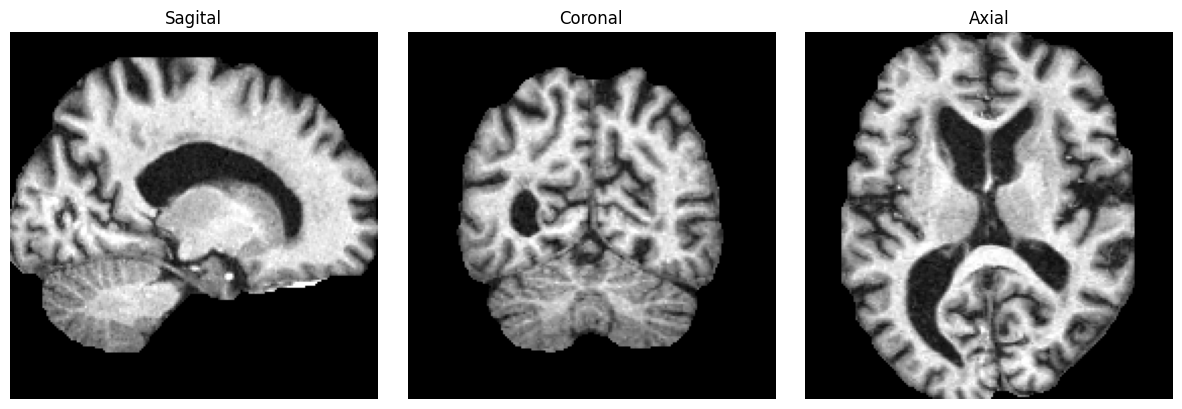

In [54]:
test_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_PROCESSED"
img = ants.image_read(f"{test_dir}/0.0/{os.listdir(f"{test_dir}/0.0")[0]}")

SLICE_NII_IDX0 = slice(24, 169)
SLICE_NII_IDX1 = slice(24, 206)
SLICE_NII_IDX2 = slice(6, 161)

data = img.numpy()[SLICE_NII_IDX0, SLICE_NII_IDX1, SLICE_NII_IDX2]
print(data.shape)
plot_views_uniforme_final(data, 1, 90, 40, 82)

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 145, 182, 155,  │            56 │
│                                 │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 145, 182, 155,  │             8 │
│ (BatchNormalization)            │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 145, 182, 155,  │             0 │
│                                 │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 73, 91, 78, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 91, 78, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 73, 91, 78, 4)  │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 91, 78, 4)  │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 73, 91, 78, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 37, 46, 39, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 46, 39, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 37, 46, 39, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 46, 39, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 37, 46, 39, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 19, 23, 20, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 23, 20, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 19, 23, 20, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 23, 20, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 19, 23, 20, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 10, 12, 10, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 12, 10, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       307,21

 Total params: 936,485 (3.57 MB)

 Trainable params: 312,125 (1.19 MB)

 Non-trainable params: 108 (432.00 B)

 Optimizer params: 624,252 (2.38 MB)

In [34]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced(test_dir, class_names)

carregando diretório 0.0
diretório carregado 85
carregando diretório 0.5
diretório carregado 52
carregando diretório 1.0
diretório carregado 13


In [35]:
# Realizar predições para dados do conjunto validação
test_true_labels, test_pred_labels, test_pred = get_predictions(test_images, test_labels, 64, model)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 19200, but received input with shape (32, 40560)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 193, 229, 193, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test', class_names)

In [ ]:
# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "oasis_test_predictions.pdf")
create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, class_names)